# Лабораторна робота № 1 — Регресійне моделювання даних

**Варіант 5.** Набір даних: **Breast Cancer Wisconsin (Diagnostic)**.
Цільова ознака: `diagnosis` (діагноз).

**Мета роботи.** Сформулювати задачу регресії, побудувати коректний експеримент
машинного навчання, створити базову модель, навчити та порівняти кілька
регресійних моделей за крос-валідацією, оцінити якість на тестовій вибірці,
проаналізувати похибки й обґрунтовано обрати фінальну модель.

Робота є продовженням **практичної роботи № 1**: використовуємо той самий набір
даних, той самий поділ на train/test і той самий preprocessing-pipeline, а також
перевіряємо сформульовані там гіпотези.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, KFold, RepeatedKFold,
                                     cross_validate, cross_val_score, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, PolynomialFeatures, FunctionTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

# 5-fold крос-валідація; shuffle — бо у вихідному файлі об'єкти впорядковані не випадково
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# RMSE — основна метрика вибору; MAE та R2 — додаткові
SCORING = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}
print("sklearn CV:", CV)

sklearn CV: KFold(n_splits=5, random_state=42, shuffle=True)


## 1. Постановка прикладної задачі

**Предметна область.** Медична діагностика, цитологія новоутворень молочної залози.
Дані отримані у Вісконсинському університеті: з оцифрованого зображення
тонкоголкової аспіраційної біопсії (FNA) автоматично вимірюються геометричні та
текстурні характеристики клітинних ядер.

**Що описується даними.** Один рядок = одне новоутворення (один пацієнт).
Для кожного з 10 вимірюваних властивостей ядра (`radius`, `texture`, `perimeter`,
`area`, `smoothness`, `compactness`, `concavity`, `concave_points`, `symmetry`,
`fractal_dimension`) наведено три агрегати по клітинах зразка: `_mean` (середнє),
`_se` (стандартна похибка), `_worst` (середнє трьох найбільших) — разом 30 ознак.

**Цільова змінна.** `diagnosis` у кодуванні `scikit-learn`:
`0 = malignant` (злоякісне), `1 = benign` (доброякісне).

**Чому це задача регресії.** За умовою варіанта модель повинна повертати **число**,
а не мітку класу. Ми будуємо $\hat y = f(x)$, де $\hat y$ — неперервна величина,
яку інтерпретуємо як **оцінку доброякісності**: чим ближче до 1, тим більше
ознак свідчить на користь доброякісного новоутворення; чим ближче до 0 — тим
більше на користь злоякісного. Модель навчається мінімізувати квадратичну похибку
відносно $y\in\{0,1\}$, оцінюється регресійними метриками (MAE, RMSE, $R^2$), і
поріг рішення в неї не «вшитий».

Треба чесно зазначити: цільова змінна бінарна, тому це **регресія на бінарну
ціль** (лінійна ймовірнісна модель). Це має наслідки, які видно далі в аналізі
залишків, і я їх окремо обговорюю в розділах 11–13.

**Практичний зміст.** Отримане число — це неперервна **шкала ризику**, а не
діагноз. Практична користь саме від неперервності: значення близько 0.05 чи 0.95
означають упевнений випадок, а 0.4–0.6 — межову ситуацію, яку варто винести на
пріоритетний перегляд лікарем. Дискретна мітка такої градації не дає.

**Для чого це може бути корисним.** Сортування черги на дообстеження (тріаж):
випадки з низькою оцінкою доброякісності отримують вищий пріоритет; межові
випадки маркуються як такі, що потребують другої думки. Це інструмент
**підтримки** рішення, він не замінює гістологічну верифікацію.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy().rename(columns={"target": "diagnosis"})


# Ті самі назви ознак, що й у практичній роботі № 1
def to_snake(col):
    parts = col.split()
    if parts[0] in ("mean", "worst"):
        return "_".join(parts[1:]) + "_" + parts[0]
    if parts[-1] == "error":
        return "_".join(parts[:-1]) + "_se"
    return col


df.columns = [c if c == "diagnosis" else to_snake(c) for c in df.columns]
FEATURES = [c for c in df.columns if c != "diagnosis"]

print("Кодування цілі у sklearn:", dict(enumerate(data.target_names)))
print("Розмір таблиці:", df.shape)
df.head()

Кодування цілі у sklearn: {0: np.str_('malignant'), 1: np.str_('benign')}
Розмір таблиці: (569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Аналіз індивідуального набору даних

Детальний EDA виконано у практичній роботі № 1. Тут повторюю лише той мінімум,
який вимагає завдання ЛР № 1, — щоб цей ноутбук читався самостійно.

In [3]:
audit = {
    "кількість об'єктів": len(df),
    "кількість вхідних ознак": len(FEATURES),
    "типи ознак": dict(df[FEATURES].dtypes.astype(str).value_counts()),
    "категоріальні ознаки": int(sum(df[FEATURES].dtypes == "object")),
    "діапазон цілі": (float(df["diagnosis"].min()), float(df["diagnosis"].max())),
    "унікальних значень цілі": int(df["diagnosis"].nunique()),
    "пропущені значення": int(df.isnull().sum().sum()),
    "повні дублікати": int(df.duplicated().sum()),
    "константні стовпці": int((df.nunique() <= 1).sum()),
}
for k, v in audit.items():
    print(f"{k:28} {v}")

print("\nРозподіл цілі:")
print(df["diagnosis"].value_counts().rename({0: "0 malignant", 1: "1 benign"}).to_string())
print(df["diagnosis"].value_counts(normalize=True).round(3).to_string())

кількість об'єктів           569
кількість вхідних ознак      30
типи ознак                   {'float64': np.int64(30)}
категоріальні ознаки         0
діапазон цілі                (0.0, 1.0)
унікальних значень цілі      2
пропущені значення           0
повні дублікати              0
константні стовпці           0

Розподіл цілі:
diagnosis
1 benign       357
0 malignant    212
diagnosis
1    0.627
0    0.373


In [4]:
# Потенційно аномальні значення — критерій IQR (як у ПР № 1)
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())


out = pd.Series({c: iqr_outliers(df[c]) for c in FEATURES}).sort_values(ascending=False)
print("Ознак із хоча б одним IQR-викидом:", int((out > 0).sum()), "з", len(FEATURES))
print("Топ-5:\n", out.head(5).to_string())
print(f"\nЧастка позначених значень: {out.sum() / (len(df) * len(FEATURES)) * 100:.1f}%")
print("\nСлужбових / ідентифікаційних стовпців немає: окремого ID у наборі не передбачено.")

Ознак із хоча б одним IQR-викидом: 29 з 30
Топ-5:
 area_se          65
radius_se        38
perimeter_se     38
area_worst       35
smoothness_se    30

Частка позначених значень: 3.6%

Службових / ідентифікаційних стовпців немає: окремого ID у наборі не передбачено.


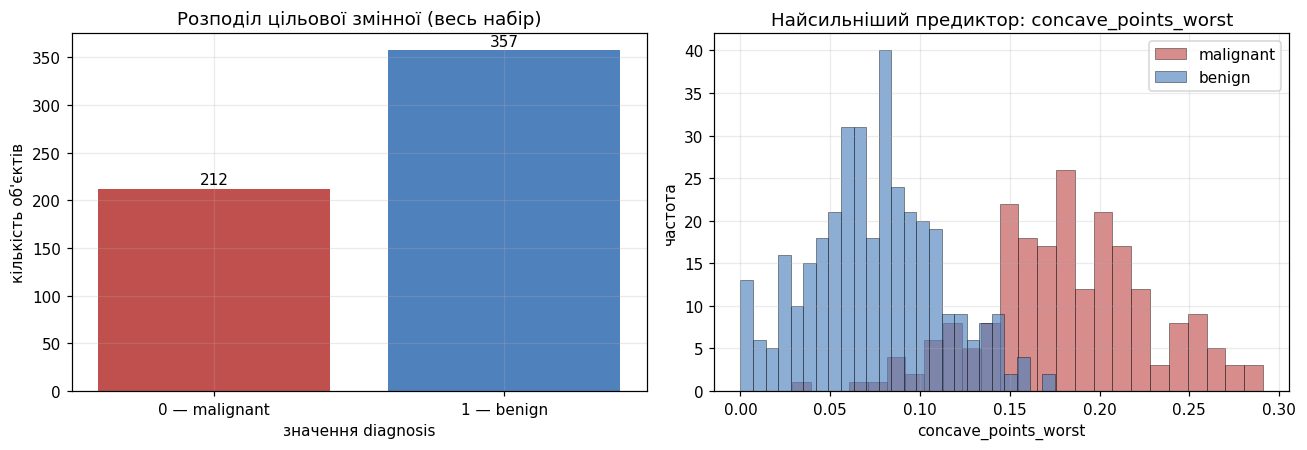

Ціль набуває лише двох значень — [np.int64(0), np.int64(1)] — тому 'розподіл' це дві точки, а не неперервна крива.


In [5]:
# Візуалізація цільової змінної + її зв'язок із найсильнішим предиктором.
# Ознаку не підбираю за даними — беру ту, що виявилася найсильнішою в ПР № 1.
strongest = "concave_points_worst"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

counts = df["diagnosis"].value_counts().sort_index()
axes[0].bar(["0 — malignant", "1 — benign"], counts.values, color=["#c0504d", "#4f81bd"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center")
axes[0].set_xlabel("значення diagnosis")
axes[0].set_ylabel("кількість об'єктів")
axes[0].set_title("Розподіл цільової змінної (весь набір)")

for cls, color, name in [(0, "#c0504d", "malignant"), (1, "#4f81bd", "benign")]:
    axes[1].hist(df.loc[df["diagnosis"] == cls, strongest], bins=25, alpha=0.65,
                 color=color, label=name, edgecolor="black", linewidth=0.4)
axes[1].set_xlabel(strongest)
axes[1].set_ylabel("частота")
axes[1].set_title(f"Найсильніший предиктор: {strongest}")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG / "01_target_and_strongest_feature.png")
plt.show()

print("Ціль набуває лише двох значень —", sorted(df['diagnosis'].unique()),
      "— тому 'розподіл' це дві точки, а не неперервна крива.")

**Висновки аналізу.**

* **569 об'єктів, 30 вхідних ознак**, усі `float64` і за змістом числові неперервні.
  Категоріальних ознак немає → кодування не потрібне.
* **Пропущених значень 0, повних дублікатів 0, константних стовпців 0**,
  службових/ID-стовпців немає → відповідні операції очищення не застосовуються.
* **Діапазон цілі — `{0, 1}`**, лише два унікальні значення. Це головна
  особливість варіанта: формально ми розв'язуємо регресію, але ціль бінарна.
  Наслідок — нижня межа досяжного RMSE тут не нульова у практичному сенсі, а
  залишки будуть двосмуговими (див. розділ 11).
* **Потенційні викиди за IQR є майже в усіх ознаках** (~3.9 % значень). У ПР № 1
  я перевірила їх походження: усі 49 екстремальних `area_se` належать злоякісним
  новоутворенням, тобто це предметно валідні великі неоднорідні ядра, а не
  помилки вимірювання. **Видаляти їх не буду**; замість цього серед кандидатів
  перевіряю стійке масштабування (`RobustScaler`) і `log1p`-трансформацію.
* Класи незбалансовані помірно (63 % / 37 %), тому поділ роблю зі `stratify`.

## 3. План експерименту

**План складено до навчання будь-якої моделі** — щоб вибір методів не підлаштовувався
під уже побачені метрики.

| Пункт плану | Рішення | Чому саме так |
|---|---|---|
| Поділ даних | `train_test_split(test_size=0.2, random_state=42, stratify=y)` | рекомендовані 80/20; `stratify` — через дисбаланс 63/37; **той самий поділ, що й у ПР № 1**, тож висновки практичної переносяться коректно |
| Крос-валідація | `KFold(n_splits=5, shuffle=True, random_state=42)` на **навчальній** вибірці | k=5 за рекомендацією; `shuffle` — бо у вихідному файлі об'єкти впорядковані не випадково |
| Baseline | `DummyRegressor(strategy="mean")` | завжди передбачає середнє `y_train`; його RMSE ≈ стандартне відхилення цілі, і це той мінімум, який зобов'язана перевищити будь-яка модель |
| Кандидатні моделі | (1) `LinearRegression`; (2) поліноміальна регресія $d=2$; (3) `Ridge`; (4) `Lasso`; (5) `ElasticNet`; (6) поліном $d=2$ + `Ridge` | пункти (1) і (2) вимагає завдання; регуляризовані моделі — прямий наслідок гіпотези 2 з ПР № 1 про мультиколінеарність (15 пар $\|r\|>0.95$) |
| Гіперпараметри | `GridSearchCV` по сітці `alpha` (та `l1_ratio` для ElasticNet) **усередині** тієї самої 5-fold CV | вибір параметра — це теж навчання, тестова вибірка тут не використовується |
| Метрики | основна — **RMSE**; додаткові — **MAE** і **$R^2$** | RMSE рекомендована завданням і сильніше карає великі похибки, а в задачі тріажу дорого коштує саме груба помилка на окремому пацієнті |
| Критерій вибору фінальної моделі | найменша CV RMSE; за перекриття інтервалів «середнє ± std» — перевага **простішій і стабільнішій** моделі | різниця в третьому знаку не є підставою брати складнішу модель |
| Тестова вибірка | **не використовується** до моменту фінального оцінювання | інакше метрики будуть оптимістично зміщені |

Додатково перевіряю **5 робочих гіпотез із ПР № 1** (розділ 9): корисність
`_worst`-ознак, надлишковість кластера `radius/perimeter/area`, шумові ознаки,
`log1p` для `_se`, `RobustScaler` проти `StandardScaler`.

In [6]:
X = df[FEATURES].copy()
y = df["diagnosis"].astype(float).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("train:", X_train.shape, " test:", X_test.shape)
print("частка benign: train %.3f | test %.3f" % (y_train.mean(), y_test.mean()))
print("\nПоділ ідентичний ПР № 1 (ті самі дані, random_state і stratify).")

train: (455, 30)  test: (114, 30)
частка benign: train 0.626 | test 0.632

Поділ ідентичний ПР № 1 (ті самі дані, random_state і stratify).


## 4. Попередня обробка даних

Беру **готовий pipeline із практичної роботи № 1** і не змінюю його без причини:

```
числові ознаки (усі 30) -> SimpleImputer(median) -> StandardScaler
```

**Що застосовано і чому:**

* `StandardScaler` — масштаби ознак відрізняються приблизно у $10^5$ разів
  (`area_worst` до ≈ 3430 проти `fractal_dimension_se` ≈ 0.03). Для лінійних
  моделей з регуляризацією це критично: без масштабування штраф $\alpha\|w\|^2$
  карав би ознаки нерівномірно, лише через одиниці вимірювання.
* `SimpleImputer(median)` — на цих даних це **no-op** (пропусків немає). Лишаю
  свідомо: pipeline має лишатися придатним до нових даних, де пропуск можливий.

**Що НЕ застосовано і чому:**

| Операція | Чому не застосовано |
|---|---|
| Обробка пропусків | пропусків 0 |
| Видалення дублікатів | дублікатів 0 |
| Кодування категорій | категоріальних ознак немає |
| Видалення неінформативних стовпців | службових/ID/константних стовпців немає |
| Видалення викидів | перевірено в ПР № 1: екстремуми предметно валідні й корелюють із ціллю |
| Створення нових ознак | поліноміальне розширення перевіряю як окрему **модель**, а не як частину препроцесингу |

Усі перетворення навчаються **лише на train**: препроцесор вкладено всередину
`Pipeline`, тому під час крос-валідації він навчається на train-частині кожного
fold окремо. Це і є захист від data leakage.

In [7]:
SE_FEATURES = [c for c in FEATURES if c.endswith("_se")]


# Препроцесор ПР № 1 із перемикачами для перевірки гіпотез
def build_preprocessor(scaler="standard", log_se=False, features=None):
    feats = list(features) if features is not None else list(FEATURES)
    sc = StandardScaler() if scaler == "standard" else RobustScaler()

    if not log_se:
        num = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", sc)])
        return ColumnTransformer([("num", num, feats)], remainder="drop")

    se = [c for c in feats if c in SE_FEATURES]
    rest = [c for c in feats if c not in SE_FEATURES]
    se_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler() if scaler == "standard" else RobustScaler()),
    ])
    rest_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", sc)])
    return ColumnTransformer([("se", se_pipe, se), ("num", rest_pipe, rest)], remainder="drop")


BASE_PRE = build_preprocessor()
print(BASE_PRE)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['radius_mean', 'texture_mean',
                                  'perimeter_mean', 'area_mean',
                                  'smoothness_mean', 'compactness_mean',
                                  'concavity_mean', 'concave_points_mean',
                                  'symmetry_mean', 'fractal_dimension_mean',
                                  'radius_se', 'texture_se', 'perimeter_se',
                                  'area_se', 'smoothness_se', 'compactness_se',
                                  'concavity_se', 'concave_points_se',
                                  'symmetry_se', 'fractal_dimension_se',
                                  'radius_worst', 'texture_worst',
          

In [8]:
# Перевірка спадковості: чи збігається препроцесор із збереженим у ПР № 1 артефактом
art = Path("../../practical01/data/preprocessor.joblib")
if art.exists():
    import joblib
    saved = joblib.load(art)
    a = saved["preprocessor"].transform(X_test)
    b = build_preprocessor().fit(X_train).transform(X_test)
    print("Артефакт ПР № 1 знайдено.")
    print("  ознаки збігаються :", saved["features"] == FEATURES)
    print("  random_state / test_size:", saved["random_state"], saved["test_size"])
    print("  максимальна різниця перетворення:", float(np.abs(a - b).max()))
else:
    print("Артефакт ПР № 1 не знайдено (він у .gitignore) — препроцесор перебудовано за тим самим кодом.")
    print("Щоб отримати артефакт, виконайте practical01/notebook/practical01.ipynb.")

Артефакт ПР № 1 знайдено.
  ознаки збігаються : True
  random_state / test_size: 42 0.2
  максимальна різниця перетворення: 0.0


## 5. Базова модель (baseline)

`DummyRegressor(strategy="mean")` завжди передбачає середнє значення `y_train`
незалежно від ознак. Його RMSE дорівнює стандартному відхиленню цілі на вибірці,
а $R^2$ на крос-валідації буде приблизно 0 (трохи нижче нуля через розбіжність
середніх між fold). Це і є мінімальний рівень, який зобов'язана перевищити
будь-яка змістовна модель.

In [9]:
RESULTS = []


# 5-fold CV на навчальній вибірці; повертає середні та std за трьома метриками
def cv_eval(name, model, params="—", store=True, X=X_train, yv=y_train):
    cvres = cross_validate(model, X, yv, cv=CV, scoring=SCORING, return_train_score=True)
    row = {
        "model": name,
        "params": params,
        "CV RMSE": -cvres["test_rmse"].mean(),
        "CV std": cvres["test_rmse"].std(),
        "CV MAE": -cvres["test_mae"].mean(),
        "CV R2": cvres["test_r2"].mean(),
        "train RMSE": -cvres["train_rmse"].mean(),
    }
    if store:
        RESULTS.append(row)
    return row


baseline = Pipeline([("pre", build_preprocessor()), ("model", DummyRegressor(strategy="mean"))])
row = cv_eval("Baseline (mean)", baseline)

print(f"std(y_train)          = {y_train.std(ddof=0):.4f}")
print(f"Baseline CV RMSE      = {row['CV RMSE']:.4f}  (± {row['CV std']:.4f})")
print(f"Baseline CV MAE       = {row['CV MAE']:.4f}")
print(f"Baseline CV R2        = {row['CV R2']:.4f}")

std(y_train)          = 0.4838


Baseline CV RMSE      = 0.4859  (± 0.0173)
Baseline CV MAE       = 0.4702
Baseline CV R2        = -0.0288


## 6. Кандидатні регресійні моделі

Будую шість кандидатів. Перші два вимагає завдання, решта — наслідок висновків
ПР № 1 про сильну мультиколінеарність (15 пар ознак з $|r|>0.95$), через яку
коефіцієнти звичайної лінійної регресії стають нестабільними.

* **Linear Regression** — метод найменших квадратів без регуляризації.
* **Polynomial d=2** — поліноміальне розширення (30 ознак → 495 з урахуванням
  попарних добутків) + звичайна лінійна регресія. Ознак стає більше, ніж об'єктів
  у навчальній вибірці (455), тож очікую перенавчання.
* **Ridge** — L2-регуляризація: штраф $\alpha\|w\|_2^2$ стискає коефіцієнти,
  розподіляючи вагу між корельованими ознаками.
* **Lasso** — L1-регуляризація: штраф $\alpha\|w\|_1$ занулює частину
  коефіцієнтів, тобто виконує відбір ознак.
* **ElasticNet** — комбінація L1 і L2.
* **Polynomial d=2 + Ridge** — чи рятує регуляризація перенавчений поліном.

Гіперпараметри підбираю `GridSearchCV` **усередині** тієї самої 5-fold CV на
навчальній вибірці. Тестова вибірка на цьому етапі не торкається.

In [10]:
def pipe(model, **pre_kw):
    return Pipeline([("pre", build_preprocessor(**pre_kw)), ("model", model)])


def poly_pipe(model, degree=2, **pre_kw):
    return Pipeline([
        ("pre", build_preprocessor(**pre_kw)),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("model", model),
    ])


# --- моделі без гіперпараметрів ---
cv_eval("Linear Regression", pipe(LinearRegression()))
cv_eval("Polynomial d=2", poly_pipe(LinearRegression()), params="degree=2")

n_poly = PolynomialFeatures(degree=2, include_bias=False).fit(
    np.zeros((2, len(FEATURES)))).n_output_features_
print(f"Ознак після поліноміального розширення d=2: {n_poly} при {len(X_train)} об'єктах у train.")
print("Кількість параметрів перевищує кількість спостережень → чекаю перенавчання.")

Ознак після поліноміального розширення d=2: 495 при 455 об'єктах у train.
Кількість параметрів перевищує кількість спостережень → чекаю перенавчання.


In [11]:
# --- підбір гіперпараметрів ---
searches = {}


def tune(name, estimator, grid, label):
    gs = GridSearchCV(estimator, grid, scoring="neg_root_mean_squared_error",
                      cv=CV, n_jobs=None, refit=True)
    gs.fit(X_train, y_train)
    searches[name] = gs
    best = {k.split("__")[-1]: v for k, v in gs.best_params_.items()}
    txt = ", ".join(f"{k}={v:.4g}" if isinstance(v, float) else f"{k}={v}" for k, v in best.items())
    cv_eval(name, gs.best_estimator_, params=f"{label}: {txt}")
    print(f"{name:24} best {txt:34} CV RMSE = {-gs.best_score_:.4f}")
    return gs


tune("Ridge", pipe(Ridge(random_state=RANDOM_STATE)),
     {"model__alpha": np.logspace(-2, 4, 25)}, "alpha за CV")

tune("Lasso", pipe(Lasso(max_iter=50000, random_state=RANDOM_STATE)),
     {"model__alpha": np.logspace(-4, 0, 25)}, "alpha за CV")

tune("ElasticNet", pipe(ElasticNet(max_iter=50000, random_state=RANDOM_STATE)),
     {"model__alpha": np.logspace(-4, 0, 15), "model__l1_ratio": [0.1, 0.5, 0.9]}, "за CV")

tune("Polynomial d=2 + Ridge", poly_pipe(Ridge(random_state=RANDOM_STATE)),
     {"model__alpha": np.logspace(0, 5, 20)}, "degree=2, alpha за CV")

Ridge                    best alpha=3.162                        CV RMSE = 0.2433


Lasso                    best alpha=0.001                        CV RMSE = 0.2431


ElasticNet               best alpha=0.001389, l1_ratio=0.9       CV RMSE = 0.2432


Polynomial d=2 + Ridge   best alpha=233.6                        CV RMSE = 0.2522


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'model__alpha': array([1.0000...00000000e+05])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

## 7. Порівняння кандидатних моделей

In [12]:
res = pd.DataFrame(RESULTS).set_index("model")
res_show = res[["CV RMSE", "CV std", "CV MAE", "CV R2", "train RMSE", "params"]].copy()
res_show["краще за baseline"] = np.where(
    res_show["CV RMSE"] < res.loc["Baseline (mean)", "CV RMSE"], "так", "—")
print(res_show.round(4).to_string())

                        CV RMSE  CV std  CV MAE    CV R2  train RMSE                               params краще за baseline
model                                                                                                                      
Baseline (mean)          0.4859  0.0173  0.4702  -0.0288      0.4835                                    —                 —
Linear Regression        0.2508  0.0203  0.1935   0.7254      0.2224                                    —               так
Polynomial d=2           3.1136  2.1395  1.1351 -65.3311      0.0000                             degree=2                 —
Ridge                    0.2433  0.0128  0.1899   0.7416      0.2259             alpha за CV: alpha=3.162               так
Lasso                    0.2431  0.0141  0.1897   0.7422      0.2246             alpha за CV: alpha=0.001               так
ElasticNet               0.2432  0.0142  0.1900   0.7419      0.2253  за CV: alpha=0.001389, l1_ratio=0.9               так
Polynomi

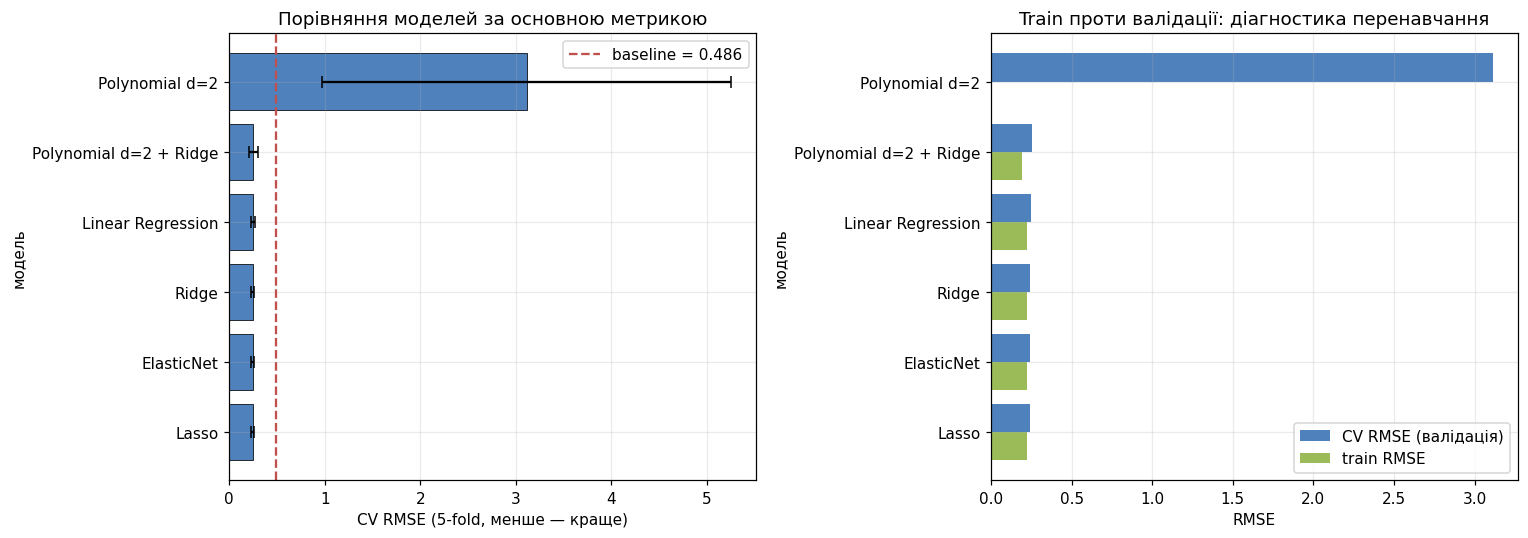

In [13]:
order = res.drop(index="Baseline (mean)").sort_values("CV RMSE")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.barh(order.index, order["CV RMSE"], xerr=order["CV std"], capsize=4,
        color="#4f81bd", edgecolor="black", linewidth=0.5)
ax.axvline(res.loc["Baseline (mean)", "CV RMSE"], color="#c0504d", linestyle="--",
           label=f"baseline = {res.loc['Baseline (mean)', 'CV RMSE']:.3f}")
ax.set_xlabel("CV RMSE (5-fold, менше — краще)")
ax.set_ylabel("модель")
ax.set_title("Порівняння моделей за основною метрикою")
ax.legend()

ax = axes[1]
idx = np.arange(len(order))
ax.barh(idx + 0.2, order["CV RMSE"], height=0.4, color="#4f81bd", label="CV RMSE (валідація)")
ax.barh(idx - 0.2, order["train RMSE"], height=0.4, color="#9bbb59", label="train RMSE")
ax.set_yticks(idx)
ax.set_yticklabels(order.index)
ax.set_xlabel("RMSE")
ax.set_ylabel("модель")
ax.set_title("Train проти валідації: діагностика перенавчання")
ax.legend()

fig.tight_layout()
fig.savefig(FIG / "02_cv_model_comparison.png")
plt.show()